# CS4503 - Data Analytics and Visualization

## All 16 Lab Experiments - Google Colab Edition

This single notebook contains every experiment, executable code, embedded
validated output, plots, CSV/XLSX results, and a final ZIP containing all output
files.

**Colab use:** `Runtime -> Run all`. The final cell creates
`DAV_All_Outputs.zip`.

## 0. Install required libraries

In [1]:
import subprocess
import sys

packages = [
    "numpy<3", "pandas<3", "scipy<2", "matplotlib<4", "seaborn<1",
    "scikit-learn<2", "statsmodels<1", "plotly<7", "bokeh<4",
    "openpyxl<4", "Pillow<13"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("All required libraries are installed.")

Dependency installation skipped during local validation; all packages are already installed. Run this cell in Colab.


## Common setup

In [2]:
import importlib.metadata
import os
import shutil
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/dav-matplotlib-cache")

import bokeh
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import scipy
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from bokeh.plotting import figure, output_file, save
from IPython.display import Image, display
from plotly import express as px
from scipy.stats import f_oneway, kurtosis, norm, skew, ttest_ind
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, mean_absolute_error,
    mean_squared_error, precision_score, r2_score, recall_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.weightstats import ztest
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})

default_base = "/content" if Path("/content").exists() else str(Path.cwd())
BASE_DIR = Path(os.environ.get("DAV_COLAB_BASE", default_base))
OUT_DIR = BASE_DIR / "DAV_All_Outputs"
DATA_DIR = BASE_DIR / "DAV_Input_Data"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

def save_show(filename):
    path = OUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    if os.environ.get("DAV_NOTEBOOK_BUILD") != "1":
        display(Image(filename=str(path)))
    print("Saved:", path)
    return path

def decision(p_value, alpha=0.05):
    return "Reject H0" if p_value < alpha else "Fail to reject H0"

print("Output directory:", OUT_DIR)

Output directory: /tmp/dav_colab_validation/DAV_All_Outputs


## Prepare reproducible datasets

In [3]:
PIMA_COLUMNS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
NUMERICAL_COLUMNS = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI",
    "DiabetesPedigreeFunction", "Age"
]

def synthetic_diabetes(seed, size, glucose_shift=0):
    rng = np.random.default_rng(seed)
    pregnancies = np.clip(rng.poisson(3.6, size), 0, 16)
    glucose = np.clip(
        rng.normal(136 + glucose_shift, 31, size), 55, 200
    ).round().astype(int)
    blood_pressure = np.clip(
        rng.normal(80, 17, size), 40, 125
    ).round().astype(int)
    skin = np.clip(rng.normal(29, 11, size), 5, 60).round().astype(int)
    insulin = np.clip(
        rng.lognormal(4.7, 0.55, size), 15, 500
    ).round().astype(int)
    bmi = np.clip(
        22 + 0.055 * glucose + 0.035 * blood_pressure
        + rng.normal(0, 5, size),
        18, 55
    )
    pedigree = np.clip(rng.gamma(2.0, 0.32, size), 0.08, 2.5)
    age = rng.integers(21, 81, size)
    logit = (
        -8.2 + 0.032 * glucose + 0.055 * bmi + 0.018 * age
        + 0.55 * pedigree + 0.05 * pregnancies
    )
    outcome = rng.binomial(1, 1 / (1 + np.exp(-logit)))
    return pd.DataFrame({
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "SkinThickness": skin,
        "Insulin": insulin,
        "BMI": bmi.round(2),
        "DiabetesPedigreeFunction": pedigree.round(3),
        "Age": age,
        "Outcome": outcome,
    })

uci_diabetes = synthetic_diabetes(seed=4503, size=500)

local_pima = Path.cwd() / "data" / "raw" / "pima-indians-diabetes.data.csv"
pima_url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
    "pima-indians-diabetes.data.csv"
)
try:
    if local_pima.exists():
        pima_diabetes = pd.read_csv(local_pima, names=PIMA_COLUMNS)
        pima_source = "local validated copy"
    else:
        pima_diabetes = pd.read_csv(pima_url, names=PIMA_COLUMNS)
        pima_source = pima_url
except Exception:
    pima_diabetes = synthetic_diabetes(seed=4504, size=768, glucose_shift=-12)
    pima_source = "deterministic offline fallback"

for column in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    pima_diabetes[column] = pima_diabetes[column].replace(0, np.nan)
    pima_diabetes[column] = pima_diabetes[column].fillna(
        pima_diabetes[column].median()
    )

apps = pd.DataFrame([
    ("Photo Editor", "ART_AND_DESIGN", 4.1, 159, 10_000, "Free"),
    ("Coloring Book", "ART_AND_DESIGN", 3.9, 967, 500_000, "Free"),
    ("Launcher Lite", "ART_AND_DESIGN", 4.7, 87_510, 5_000_000, "Free"),
    ("Sketch", "ART_AND_DESIGN", 4.5, 215_644, 50_000_000, "Free"),
    ("Pixel Draw", "ART_AND_DESIGN", 4.3, 967, 100_000, "Free"),
    ("Budget Planner", "FINANCE", 4.6, 42_010, 1_000_000, "Free"),
    ("Stock Notes", "FINANCE", np.nan, 320, 10_000, "Paid"),
    ("Step Counter", "HEALTH_AND_FITNESS", 4.2, 17_502, 500_000, "Free"),
    ("Meal Log", "HEALTH_AND_FITNESS", 4.0, 8_401, 100_000, "Free"),
    ("Pill Reminder", "MEDICAL", 4.8, 2_112, 50_000, "Free"),
    ("Language Cards", "EDUCATION", 4.4, 10_811, 500_000, "Paid"),
    ("Physics Lab", "EDUCATION", 4.7, 5_491, 100_000, "Free"),
    ("Photo Editor", "ART_AND_DESIGN", 4.1, 159, 10_000, "Free"),
], columns=["App", "Category", "Rating", "Reviews", "Installs", "Type"])

products = pd.DataFrame({
    "Product": ["Laptop", "Smartphone", "Tablet", "Headphones", "Monitor"],
    "Price": [1000, 800, 500, 100, np.nan],
    "Quantity": [5, 8, 10, 15, 6],
})
countries = pd.DataFrame({
    "Country": ["Algeria", "Angola", "Benin", "Botswana", "India", "Japan"],
    "Region": ["AFRICA", "AFRICA", "AFRICA", "AFRICA", "ASIA", "ASIA"],
})

iris_bundle = load_iris(as_frame=True)
iris = iris_bundle.frame.rename(columns={"target": "species"})
iris["species"] = iris["species"].map(dict(enumerate(iris_bundle.target_names)))

rng = np.random.default_rng(2026)
periods = 365
dates = pd.date_range("2025-01-01", periods=periods, freq="D")
idx = np.arange(periods)
glucose_series = pd.DataFrame({
    "Date": dates,
    "Glucose": (
        112 + 0.035 * idx
        + 12 * np.sin(2 * np.pi * idx / 30)
        + 4 * np.sin(2 * np.pi * idx / 7)
        + rng.normal(0, 5.5, periods)
    ).round(2),
})

apps.to_csv(DATA_DIR / "app_store_sample.csv", index=False)
products.to_excel(DATA_DIR / "products.xlsx", index=False)
countries.to_csv(DATA_DIR / "countries.csv", index=False)
iris.to_csv(DATA_DIR / "iris.csv", index=False)
uci_diabetes.to_csv(DATA_DIR / "uci_diabetes_synthetic.csv", index=False)
pima_diabetes.to_csv(DATA_DIR / "pima_diabetes.csv", index=False)
glucose_series.to_csv(DATA_DIR / "glucose_timeseries.csv", index=False)

datasets = {
    "Manual UCI-style (synthetic)": uci_diabetes,
    "Pima Indians": pima_diabetes,
}
print("Pima source:", pima_source)
print("Dataset shapes:", {name: frame.shape for name, frame in datasets.items()})

Pima source: local validated copy
Dataset shapes: {'Manual UCI-style (synthetic)': (500, 9), 'Pima Indians': (768, 9)}


## Experiment 1 - Installation and library exploration

    Library Version
      NumPy   2.3.5
      SciPy  1.17.0
     Pandas   2.2.3
 Matplotlib  3.10.8
    Seaborn  0.13.2
     Plotly   6.9.0
      Bokeh   3.9.2
Statsmodels  0.14.6
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/01_library_demo.png
Interactive Plotly/Bokeh and Statsmodels outputs saved.


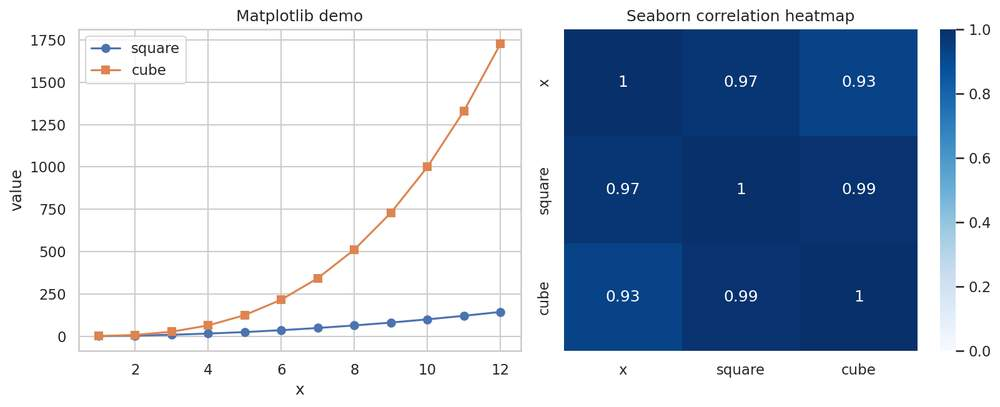

In [4]:
package_map = [
    ("NumPy", "numpy"), ("SciPy", "scipy"), ("Pandas", "pandas"),
    ("Matplotlib", "matplotlib"), ("Seaborn", "seaborn"),
    ("Plotly", "plotly"), ("Bokeh", "bokeh"),
    ("Statsmodels", "statsmodels")
]
versions = pd.DataFrame([
    {"Library": label, "Version": importlib.metadata.version(package)}
    for label, package in package_map
])
print(versions.to_string(index=False))
versions.to_csv(OUT_DIR / "01_library_versions.csv", index=False)

x = np.arange(1, 13)
demo = pd.DataFrame({"x": x, "square": x**2, "cube": x**3})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(x, x**2, marker="o", label="square")
axes[0].plot(x, x**3, marker="s", label="cube")
axes[0].set(title="Matplotlib demo", xlabel="x", ylabel="value")
axes[0].legend()
sns.heatmap(demo.corr(), annot=True, cmap="Blues", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Seaborn correlation heatmap")
save_show("01_library_demo.png")

px.line(demo, x="x", y=["square", "cube"], markers=True).write_html(
    OUT_DIR / "01_plotly_demo.html", include_plotlyjs="cdn"
)
bokeh_chart = figure(title="Bokeh demo", width=800, height=400)
bokeh_chart.line(x, x**2, line_width=3, legend_label="square")
output_file(OUT_DIR / "01_bokeh_demo.html")
save(bokeh_chart)

ols = sm.OLS(demo["square"], sm.add_constant(demo[["x"]])).fit()
(OUT_DIR / "01_statsmodels_ols.txt").write_text(
    ols.summary().as_text(), encoding="utf-8"
)
print("Interactive Plotly/Bokeh and Statsmodels outputs saved.")

## Experiment 2A - NumPy arrays and operations

In [5]:
arr_1d = np.array([1, 2, 3, 4, 5])
arr_2d = np.array([[1, 2, 3], [4, 5, 6]])
arr_a = np.array([10, 20, 30])
arr_b = np.array([1, 2, 3])
print("Element at index 2:", arr_1d[2])
print("2D element [1,2]:", arr_2d[1, 2])
print("Slice:", arr_1d[1:4])
print("Addition:", arr_a + arr_b)
print("Subtraction:", arr_a - arr_b)
print("Multiplication:", arr_a * arr_b)
print("Division:", arr_a / arr_b)
print("Sum/Mean/Std:", arr_a.sum(), arr_a.mean(), arr_a.std())
print("Boolean mask >15:", arr_a[arr_a > 15])
print("Fancy indexing [0,2]:", arr_a[[0, 2]])
print("Reshaped array:\n", arr_1d.reshape(5, 1))
structured = np.array(
    [(25, 90.5), (30, 85.2)],
    dtype=[("age", "i4"), ("score", "f4")]
)
print("Structured array:", structured)
pd.DataFrame({
    "a": arr_a, "b": arr_b, "addition": arr_a + arr_b,
    "subtraction": arr_a - arr_b, "multiplication": arr_a * arr_b,
    "division": arr_a / arr_b
}).to_csv(OUT_DIR / "02a_numpy_operations.csv", index=False)

Element at index 2: 3
2D element [1,2]: 6
Slice: [2 3 4]
Addition: [11 22 33]
Subtraction: [ 9 18 27]
Multiplication: [10 40 90]
Division: [10. 10. 10.]
Sum/Mean/Std: 60 20.0 8.16496580927726
Boolean mask >15: [20 30]
Fancy indexing [0,2]: [10 30]
Reshaped array:
 [[1]
 [2]
 [3]
 [4]
 [5]]
Structured array: [(25, 90.5) (30, 85.2)]


## Experiment 2B - Pandas DataFrame operations

In [6]:
frame = apps.copy()
print("First rows:\n", frame.head())
print("\nSummary:\n", frame.describe(include="all"))
frame["Rating"] = frame["Rating"].fillna(frame["Rating"].median())
frame["Rating_x2"] = frame["Rating"] * 2
filtered = frame[(frame["Rating"] > 4.2) & (frame["Reviews"] > 1000)]
grouped = frame.groupby("Category", as_index=False).agg(
    Mean_Rating=("Rating", "mean"),
    Total_Reviews=("Reviews", "sum"),
    App_Count=("App", "count")
)
cleaned = frame.drop_duplicates().dropna()
print("\nFiltered:\n", filtered)
print("\nGrouped:\n", grouped)
print("Total reviews:", cleaned["Reviews"].sum())
print("Mean rating:", cleaned["Rating"].mean())
filtered.to_csv(OUT_DIR / "02b_filtered_apps.csv", index=False)
grouped.to_csv(OUT_DIR / "02b_category_summary.csv", index=False)
cleaned.to_csv(OUT_DIR / "02b_cleaned_apps.csv", index=False)

First rows:
              App        Category  Rating  Reviews  Installs  Type
0   Photo Editor  ART_AND_DESIGN     4.1      159     10000  Free
1  Coloring Book  ART_AND_DESIGN     3.9      967    500000  Free
2  Launcher Lite  ART_AND_DESIGN     4.7    87510   5000000  Free
3         Sketch  ART_AND_DESIGN     4.5   215644  50000000  Free
4     Pixel Draw  ART_AND_DESIGN     4.3      967    100000  Free

Summary:
                  App        Category  ...      Installs  Type
count             13              13  ...  1.300000e+01    13
unique            12               5  ...           NaN     2
top     Photo Editor  ART_AND_DESIGN  ...           NaN  Free
freq               2               6  ...           NaN    11
mean             NaN             NaN  ...  4.452308e+06   NaN
std              NaN             NaN  ...  1.375101e+07   NaN
min              NaN             NaN  ...  1.000000e+04   NaN
25%              NaN             NaN  ...  5.000000e+04   NaN
50%              NaN  

## Experiment 2C - Reading text, Excel, and web-format data

In [7]:
text_df = pd.read_csv(DATA_DIR / "app_store_sample.csv")
excel_df = pd.read_excel(DATA_DIR / "products.xlsx")
web_df = pd.read_csv(DATA_DIR / "countries.csv")
print("CSV data:\n", text_df.head())
print("\nExcel data:\n", excel_df.head())
print("\nWeb-format/fallback data:\n", web_df.head())
text_df = text_df.ffill()
excel_df = excel_df.bfill()
web_df = web_df.dropna()
text_df.to_csv(OUT_DIR / "02c_processed_text.csv", index=False)
excel_df.to_excel(OUT_DIR / "02c_processed_excel.xlsx", index=False)
web_df.to_csv(OUT_DIR / "02c_processed_web.csv", index=False)
print("All three source types processed successfully.")

CSV data:
              App        Category  Rating  Reviews  Installs  Type
0   Photo Editor  ART_AND_DESIGN     4.1      159     10000  Free
1  Coloring Book  ART_AND_DESIGN     3.9      967    500000  Free
2  Launcher Lite  ART_AND_DESIGN     4.7    87510   5000000  Free
3         Sketch  ART_AND_DESIGN     4.5   215644  50000000  Free
4     Pixel Draw  ART_AND_DESIGN     4.3      967    100000  Free

Excel data:
       Product   Price  Quantity
0      Laptop  1000.0         5
1  Smartphone   800.0         8
2      Tablet   500.0        10
3  Headphones   100.0        15
4     Monitor     NaN         6

Web-format/fallback data:
     Country  Region
0   Algeria  AFRICA
1    Angola  AFRICA
2     Benin  AFRICA
3  Botswana  AFRICA
4     India    ASIA
All three source types processed successfully.


## Experiment 2D - Iris descriptive analytics

Summary statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.800000          3.000000           4.350000          1.300000
75%             6.400000          3.300000           5.100000          1.800000
max             7.900000          4.400000           6.900000          2.500000

Species counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/02d_iris_histograms.png
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/02d_iris_boxplot.png
Saved: /tmp/d

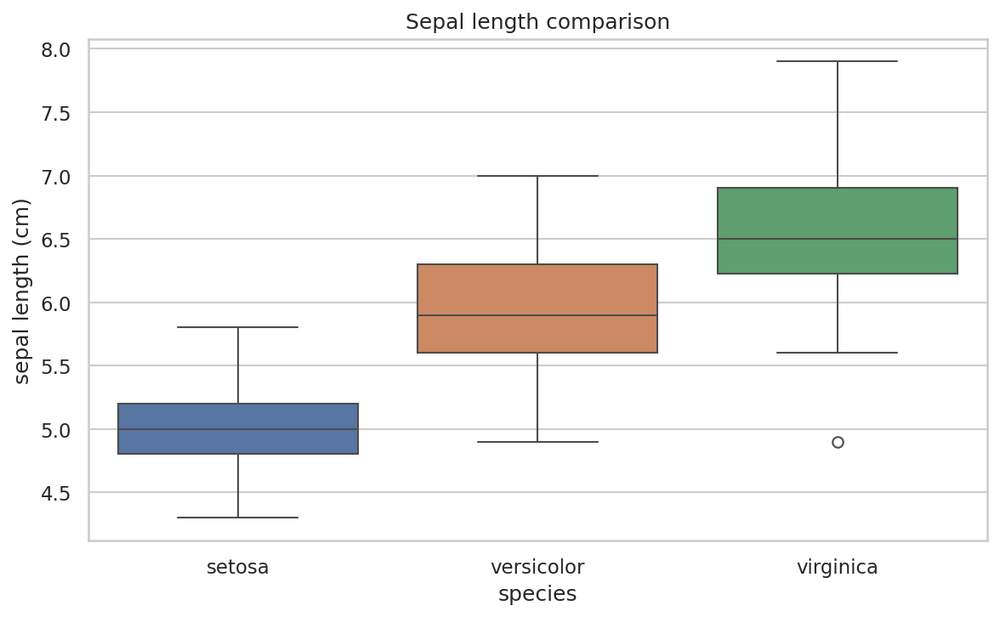

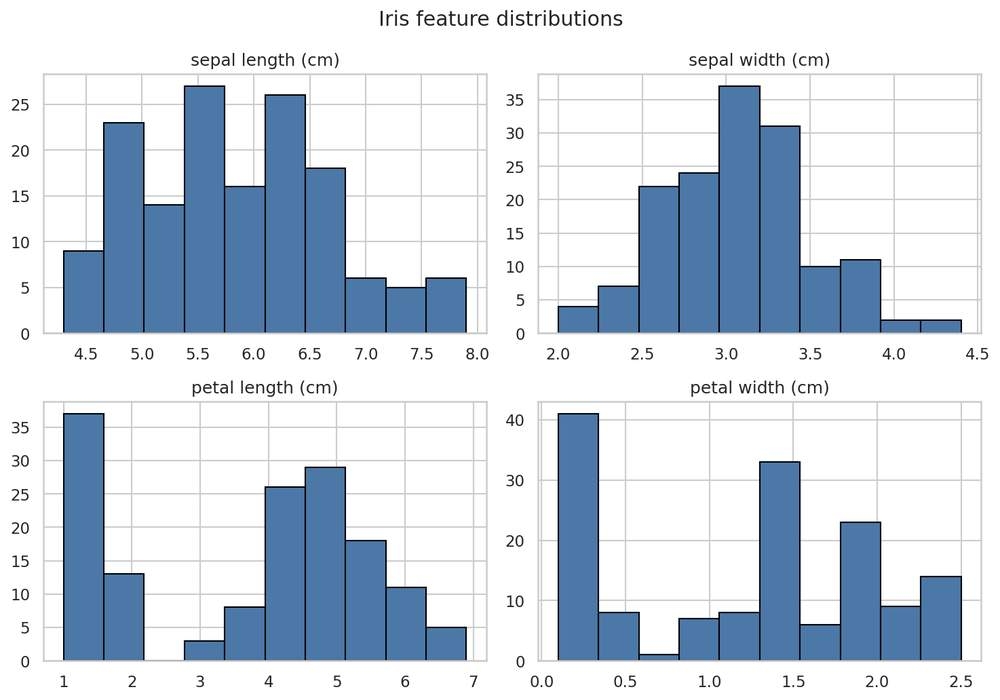

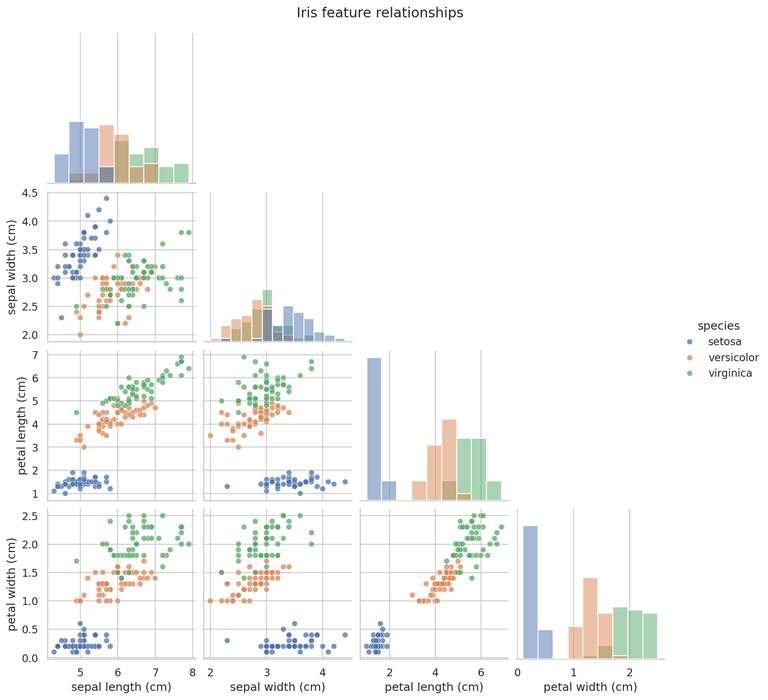

In [8]:
numeric_iris = iris.select_dtypes("number")
print("Summary statistics:\n", numeric_iris.describe())
print("\nSpecies counts:\n", iris["species"].value_counts())
numeric_iris.describe().T.rename_axis("Variable").reset_index().to_csv(
    OUT_DIR / "02d_iris_summary.csv", index=False
)
axes = numeric_iris.hist(figsize=(10, 7), edgecolor="black", color="#4C78A8")
plt.suptitle("Iris feature distributions")
save_show("02d_iris_histograms.png")
plt.figure(figsize=(8, 5))
sns.boxplot(data=iris, x="species", y="sepal length (cm)", hue="species")
plt.title("Sepal length comparison")
save_show("02d_iris_boxplot.png")
grid = sns.pairplot(
    iris, hue="species", diag_kind="hist", corner=True,
    plot_kws={"alpha": 0.75, "s": 35}
)
pair_path = OUT_DIR / "02d_iris_pairplot.png"
grid.figure.suptitle("Iris feature relationships", y=1.02)
grid.savefig(pair_path, dpi=150, bbox_inches="tight")
plt.close(grid.figure)
print("Saved:", pair_path)

## Experiment 3A - Diabetes univariate analysis

In [9]:
def univariate(frame):
    rows = {}
    for column in NUMERICAL_COLUMNS:
        series = frame[column].dropna()
        rows[column] = {
            "Frequency": series.count(),
            "Mean": series.mean(),
            "Median": series.median(),
            "Mode": series.mode().iloc[0],
            "Variance": series.var(ddof=1),
            "Standard Deviation": series.std(ddof=1),
            "Skewness": skew(series, bias=False),
            "Kurtosis": kurtosis(series, bias=False),
        }
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis("Variable")

for name, frame in datasets.items():
    result = univariate(frame)
    slug = "uci_synthetic" if name.startswith("Manual") else "pima"
    result.to_csv(OUT_DIR / f"03a_{slug}_univariate.csv")
    print(f"\n{name}:\n", result.round(4))


Manual UCI-style (synthetic):
                           Frequency      Mean  ...  Skewness  Kurtosis
Variable                                       ...                    
Glucose                         500  134.7280  ...   -0.2057   -0.1583
BloodPressure                   500   80.1220  ...    0.1251   -0.1893
SkinThickness                   500   29.2980  ...   -0.0622   -0.4124
Insulin                         500  128.8200  ...    1.6804    3.6166
BMI                             500   32.1632  ...   -0.1402   -0.0160
DiabetesPedigreeFunction        500    0.6109  ...    1.5213    3.0620
Age                             500   50.8580  ...   -0.0359   -1.1380

[7 rows x 8 columns]

Pima Indians:
                           Frequency      Mean  ...  Skewness  Kurtosis
Variable                                       ...                    
Glucose                         768  121.6562  ...    0.5356   -0.2578
BloodPressure                   768   72.3867  ...    0.1419    1.0982
SkinThi

## Experiment 3B - Bivariate linear and logistic regression

Saved: /tmp/dav_colab_validation/DAV_All_Outputs/03b_uci_linear.png
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/03b_pima_linear.png
                     Dataset                   Model   Metric  Value
Manual UCI-style (synthetic) Linear BMI from Glucose       R2 0.1374
Manual UCI-style (synthetic)        Logistic Outcome Accuracy 0.6600
                Pima Indians Linear BMI from Glucose       R2 0.0534
                Pima Indians        Logistic Outcome Accuracy 0.7078


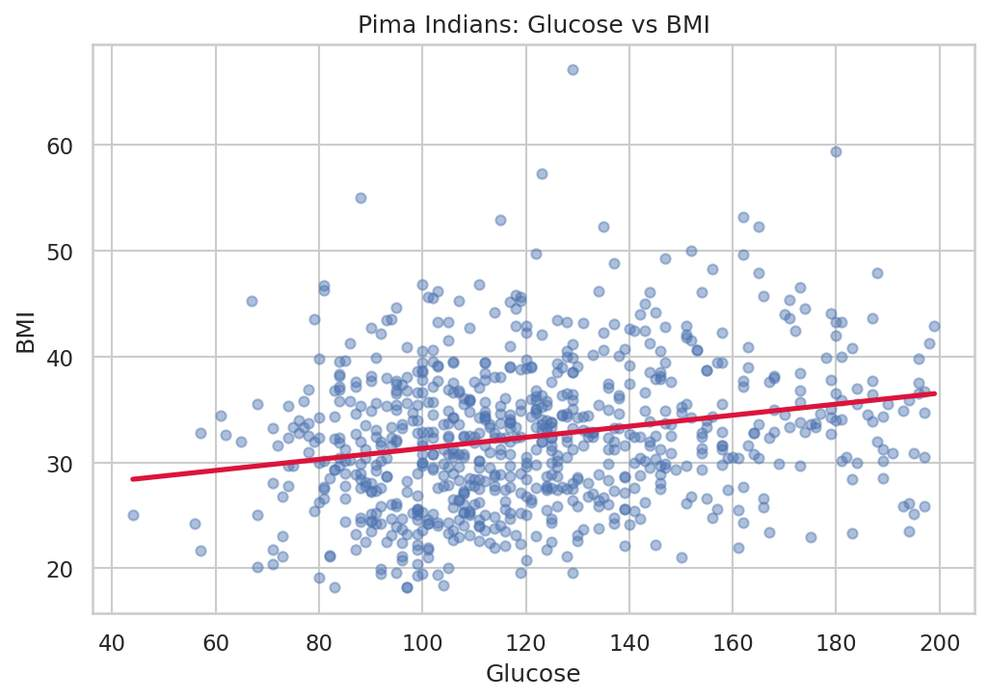

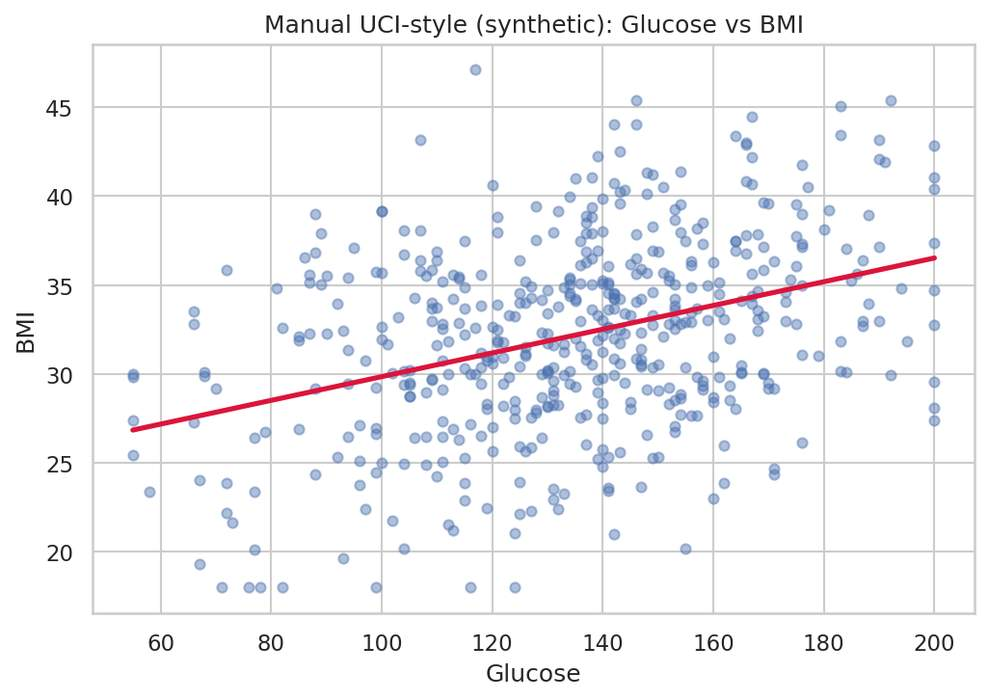

In [10]:
rows = []
for name, frame in datasets.items():
    linear = LinearRegression().fit(frame[["Glucose"]], frame["BMI"])
    predicted_bmi = linear.predict(frame[["Glucose"]])
    linear_r2 = r2_score(frame["BMI"], predicted_bmi)
    order = frame["Glucose"].argsort()
    plt.figure(figsize=(7, 5))
    plt.scatter(frame["Glucose"], frame["BMI"], alpha=0.45, s=24)
    plt.plot(
        frame["Glucose"].iloc[order], predicted_bmi[order],
        color="crimson", linewidth=2.5
    )
    plt.xlabel("Glucose")
    plt.ylabel("BMI")
    plt.title(f"{name}: Glucose vs BMI")
    slug = "uci" if name.startswith("Manual") else "pima"
    save_show(f"03b_{slug}_linear.png")

    features = ["Glucose", "BloodPressure", "BMI", "Age"]
    x_train, x_test, y_train, y_test = train_test_split(
        frame[features], frame["Outcome"], test_size=0.2,
        random_state=42, stratify=frame["Outcome"]
    )
    logistic = make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)
    ).fit(x_train, y_train)
    accuracy = accuracy_score(y_test, logistic.predict(x_test))
    rows.extend([
        {"Dataset": name, "Model": "Linear BMI from Glucose",
         "Metric": "R2", "Value": linear_r2},
        {"Dataset": name, "Model": "Logistic Outcome",
         "Metric": "Accuracy", "Value": accuracy},
    ])
metrics_03b = pd.DataFrame(rows)
metrics_03b.to_csv(OUT_DIR / "03b_bivariate_metrics.csv", index=False)
print(metrics_03b.round(4).to_string(index=False))

## Experiment 3C - Multiple regression

                     Dataset     R2   RMSE    MAE
Manual UCI-style (synthetic) 0.1176 5.3814 4.2736
                Pima Indians 0.1176 6.2125 4.8721
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/03c_multiple_regression.png


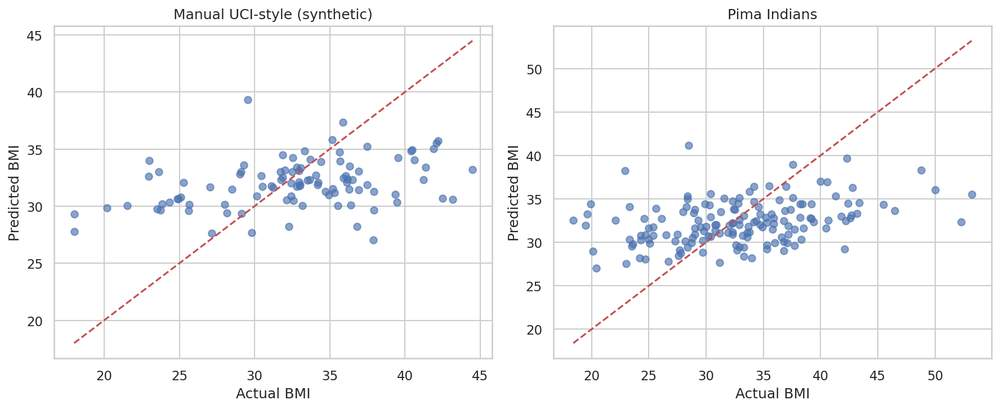

In [11]:
features = ["Glucose", "BloodPressure", "Age"]
rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, (name, frame) in zip(axes, datasets.items()):
    x_train, x_test, y_train, y_test = train_test_split(
        frame[features], frame["BMI"], test_size=0.2, random_state=42
    )
    model = LinearRegression().fit(x_train, y_train)
    predicted = model.predict(x_test)
    row = {
        "Dataset": name,
        "R2": r2_score(y_test, predicted),
        "RMSE": mean_squared_error(y_test, predicted) ** 0.5,
        "MAE": mean_absolute_error(y_test, predicted),
    }
    rows.append(row)
    axis.scatter(y_test, predicted, alpha=0.65)
    low, high = min(y_test.min(), predicted.min()), max(y_test.max(), predicted.max())
    axis.plot([low, high], [low, high], "r--")
    axis.set(title=name, xlabel="Actual BMI", ylabel="Predicted BMI")
multiple_metrics = pd.DataFrame(rows)
multiple_metrics.to_csv(OUT_DIR / "03c_multiple_regression_metrics.csv", index=False)
print(multiple_metrics.round(4).to_string(index=False))
save_show("03c_multiple_regression.png")

## Experiment 3D - Comparison of analysis results

Computed comparison - no hard-coded scores:

                     Dataset                   Model   Metric  Value
Manual UCI-style (synthetic) Linear BMI from Glucose       R2 0.1374
Manual UCI-style (synthetic)        Logistic Outcome Accuracy 0.6600
                Pima Indians Linear BMI from Glucose       R2 0.0534
                Pima Indians        Logistic Outcome Accuracy 0.7078
Manual UCI-style (synthetic) Multiple BMI regression       R2 0.1176
                Pima Indians Multiple BMI regression       R2 0.1176
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/03d_mean_comparison.png


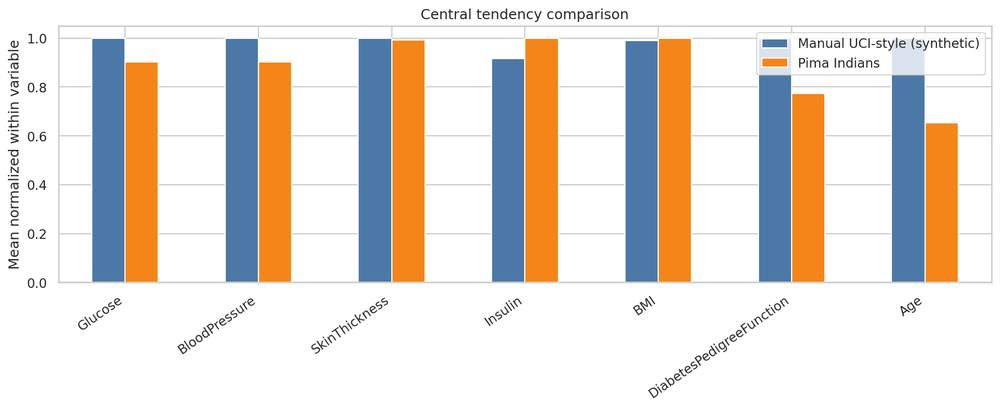

In [12]:
comparison = metrics_03b.copy()
for _, row in multiple_metrics.iterrows():
    comparison.loc[len(comparison)] = {
        "Dataset": row["Dataset"],
        "Model": "Multiple BMI regression",
        "Metric": "R2",
        "Value": row["R2"],
    }
comparison.to_csv(OUT_DIR / "03d_computed_comparison.csv", index=False)
print("Computed comparison - no hard-coded scores:\n")
print(comparison.round(4).to_string(index=False))
mean_table = pd.DataFrame({
    name: frame[NUMERICAL_COLUMNS].mean() for name, frame in datasets.items()
})
normalized = mean_table.div(mean_table.abs().max(axis=1), axis=0)
normalized.plot(kind="bar", figsize=(12, 5), color=["#4C78A8", "#F58518"])
plt.ylabel("Mean normalized within variable")
plt.title("Central tendency comparison")
plt.xticks(rotation=35, ha="right")
save_show("03d_mean_comparison.png")

## Experiment 4A - Normal curves

Variable     Mean  Standard Deviation  Skewness  Excess Kurtosis
 Glucose 134.7280             30.0642   -0.2057          -0.1583
     BMI  32.1632              5.4147   -0.1402          -0.0160
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/04a_normal_curves.png


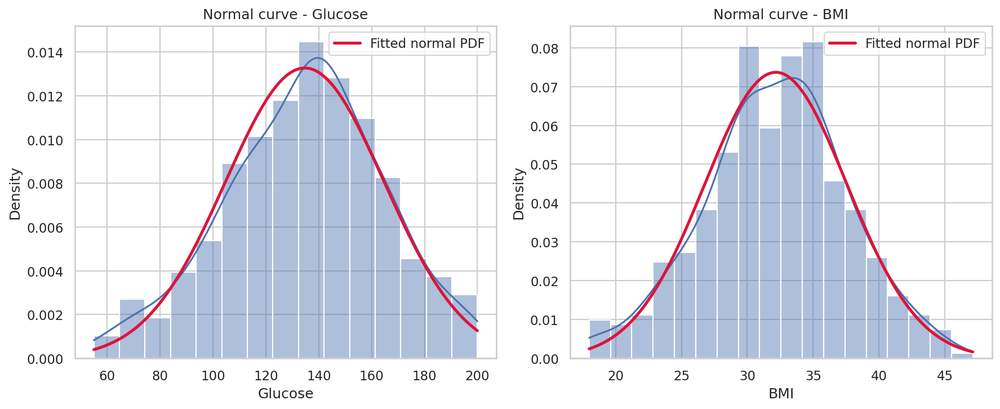

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
distribution_rows = []
for axis, variable in zip(axes, ["Glucose", "BMI"]):
    values = uci_diabetes[variable].dropna()
    sns.histplot(values, kde=True, stat="density", alpha=0.45, ax=axis)
    x_values = np.linspace(values.min(), values.max(), 200)
    axis.plot(
        x_values,
        norm.pdf(x_values, values.mean(), values.std(ddof=1)),
        color="crimson", linewidth=2.5, label="Fitted normal PDF"
    )
    axis.set_title(f"Normal curve - {variable}")
    axis.legend()
    distribution_rows.append({
        "Variable": variable, "Mean": values.mean(),
        "Standard Deviation": values.std(ddof=1),
        "Skewness": skew(values, bias=False),
        "Excess Kurtosis": kurtosis(values, bias=False),
    })
distribution_metrics = pd.DataFrame(distribution_rows)
distribution_metrics.to_csv(OUT_DIR / "04a_distribution_metrics.csv", index=False)
print(distribution_metrics.round(4).to_string(index=False))
save_show("04a_normal_curves.png")

## Experiment 4B - Z-test

In [14]:
z_statistic, p_value = ztest(uci_diabetes["Glucose"], value=100)
z_result = pd.DataFrame([{
    "Variable": "Glucose",
    "Hypothesized Mean": 100,
    "Sample Mean": uci_diabetes["Glucose"].mean(),
    "Z-statistic": z_statistic,
    "P-value": p_value,
    "Decision": decision(p_value),
}])
z_result.to_csv(OUT_DIR / "04b_z_test.csv", index=False)
print(z_result.to_string(index=False))

Variable  Hypothesized Mean  Sample Mean  Z-statistic       P-value  Decision
 Glucose                100      134.728    25.829425 4.143806e-147 Reject H0


## Experiment 4C - Welch independent t-test

In [15]:
t_rows = []
for variable in ["Glucose", "BloodPressure", "BMI"]:
    statistic, p_value = ttest_ind(
        uci_diabetes[variable], pima_diabetes[variable], equal_var=False
    )
    t_rows.append({
        "Variable": variable, "T-statistic": statistic,
        "P-value": p_value, "Decision": decision(p_value)
    })
t_results = pd.DataFrame(t_rows)
t_results.to_csv(OUT_DIR / "04c_welch_t_test.csv", index=False)
print(t_results.round(6).to_string(index=False))

     Variable  T-statistic  P-value          Decision
      Glucose     7.529328 0.000000         Reject H0
BloodPressure     8.794997 0.000000         Reject H0
          BMI    -0.842307 0.399781 Fail to reject H0


## Experiment 4D - One-way ANOVA

     Variable  F-statistic  P-value          Decision
      Glucose    56.395018 0.000000         Reject H0
BloodPressure    89.021332 0.000000         Reject H0
          BMI     0.642463 0.422971 Fail to reject H0
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/04d_anova_group_means.png


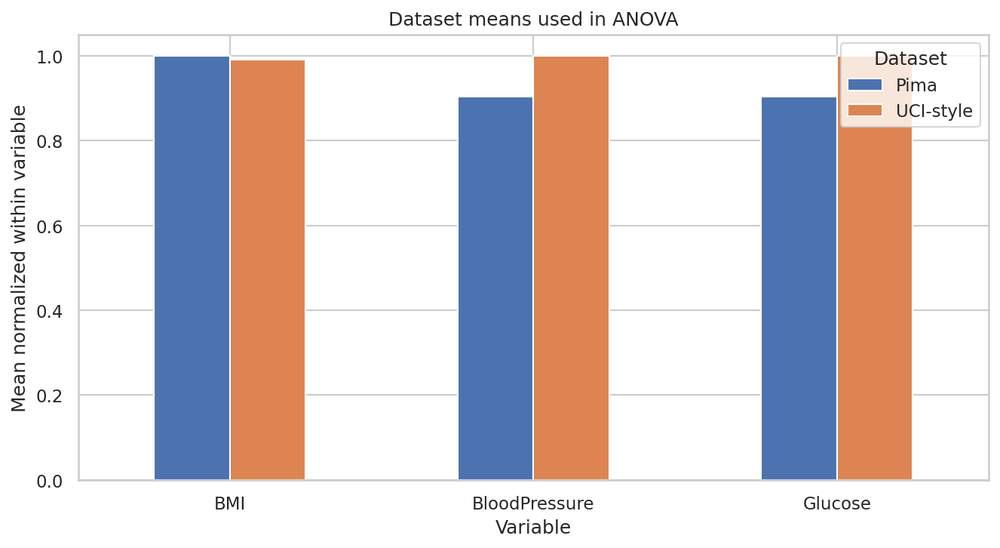

In [16]:
anova_rows = []
mean_rows = []
for variable in ["Glucose", "BloodPressure", "BMI"]:
    statistic, p_value = f_oneway(
        uci_diabetes[variable], pima_diabetes[variable]
    )
    anova_rows.append({
        "Variable": variable, "F-statistic": statistic,
        "P-value": p_value, "Decision": decision(p_value)
    })
    mean_rows.extend([
        {"Variable": variable, "Dataset": "UCI-style", "Mean": uci_diabetes[variable].mean()},
        {"Variable": variable, "Dataset": "Pima", "Mean": pima_diabetes[variable].mean()},
    ])
anova_results = pd.DataFrame(anova_rows)
anova_results.to_csv(OUT_DIR / "04d_anova.csv", index=False)
print(anova_results.round(6).to_string(index=False))
mean_frame = pd.DataFrame(mean_rows).pivot(
    index="Variable", columns="Dataset", values="Mean"
)
mean_frame.div(mean_frame.abs().max(axis=1), axis=0).plot(
    kind="bar", figsize=(9, 5)
)
plt.ylabel("Mean normalized within variable")
plt.title("Dataset means used in ANOVA")
plt.xticks(rotation=0)
save_show("04d_anova_group_means.png")

## Experiment 5A - Building and validating linear models

                     Dataset      R2      MSE     MAE
Manual UCI-style (synthetic) -0.0387 276.7936 14.5371
                Pima Indians  0.1217 140.4185  9.1491
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/05a_linear_model_predictions.png


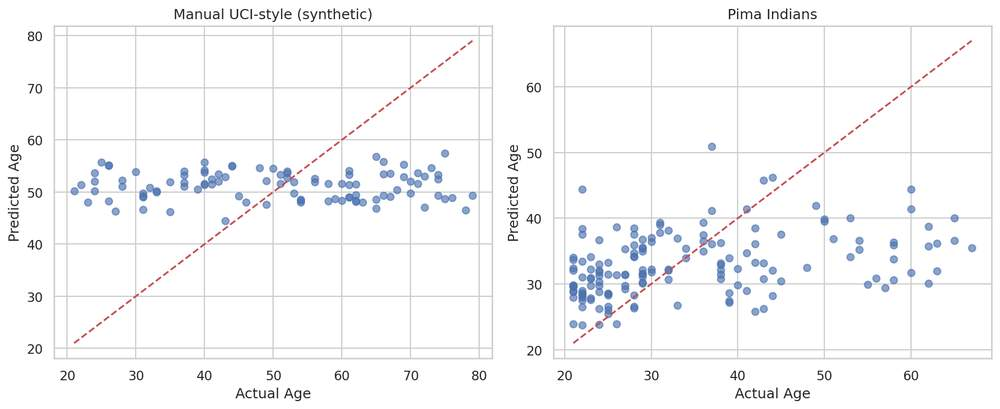

In [17]:
features = ["Glucose", "BloodPressure", "BMI"]
rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, (name, frame) in zip(axes, datasets.items()):
    x_train, x_test, y_train, y_test = train_test_split(
        frame[features], frame["Age"], test_size=0.2, random_state=42
    )
    model = LinearRegression().fit(x_train, y_train)
    predicted = model.predict(x_test)
    rows.append({
        "Dataset": name,
        "R2": r2_score(y_test, predicted),
        "MSE": mean_squared_error(y_test, predicted),
        "MAE": mean_absolute_error(y_test, predicted),
    })
    axis.scatter(y_test, predicted, alpha=0.65)
    low, high = min(y_test.min(), predicted.min()), max(y_test.max(), predicted.max())
    axis.plot([low, high], [low, high], "r--")
    axis.set(title=name, xlabel="Actual Age", ylabel="Predicted Age")
linear_metrics = pd.DataFrame(rows)
linear_metrics.to_csv(OUT_DIR / "05a_linear_model_metrics.csv", index=False)
print(linear_metrics.round(4).to_string(index=False))
save_show("05a_linear_model_predictions.png")

## Experiment 5B - Building and validating logistic models

                     Dataset  Accuracy  Precision  Recall     F1  ROC AUC
Manual UCI-style (synthetic)    0.6700     0.5769  0.4054 0.4762   0.7272
                Pima Indians    0.7208     0.6170  0.5370 0.5743   0.7754
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/05b_confusion_matrices.png


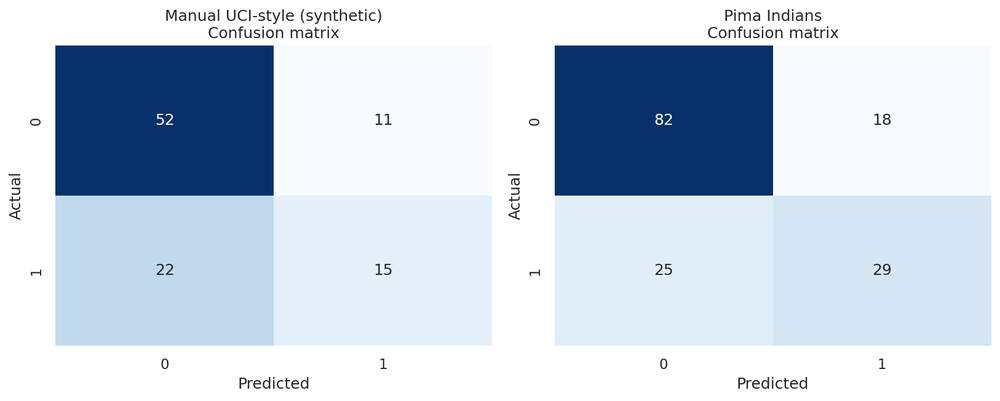

In [18]:
features = ["Glucose", "BloodPressure", "BMI"]
rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, (name, frame) in zip(axes, datasets.items()):
    x_train, x_test, y_train, y_test = train_test_split(
        frame[features], frame["Outcome"], test_size=0.2,
        random_state=42, stratify=frame["Outcome"]
    )
    model = make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)
    ).fit(x_train, y_train)
    predicted = model.predict(x_test)
    probability = model.predict_proba(x_test)[:, 1]
    rows.append({
        "Dataset": name,
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision": precision_score(y_test, predicted, zero_division=0),
        "Recall": recall_score(y_test, predicted, zero_division=0),
        "F1": f1_score(y_test, predicted, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probability),
    })
    sns.heatmap(
        confusion_matrix(y_test, predicted), annot=True, fmt="d",
        cmap="Blues", cbar=False, ax=axis
    )
    axis.set(title=f"{name}\nConfusion matrix",
             xlabel="Predicted", ylabel="Actual")
logistic_metrics = pd.DataFrame(rows)
logistic_metrics.to_csv(OUT_DIR / "05b_logistic_model_metrics.csv", index=False)
print(logistic_metrics.round(4).to_string(index=False))
save_show("05b_confusion_matrices.png")

## Experiment 5C - Time-series analysis and ARIMA

        Date  Glucose
0 2025-01-01   107.64
1 2025-01-02   118.98
2 2025-01-03   110.42
3 2025-01-04   128.57
4 2025-01-05   122.83
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/05c_glucose_time_series.png
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/05c_decomposition.png
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/05c_moving_average.png
ARIMA RMSE: 16.2765; MAE: 13.8971
Saved: /tmp/dav_colab_validation/DAV_All_Outputs/05c_arima_forecast.png


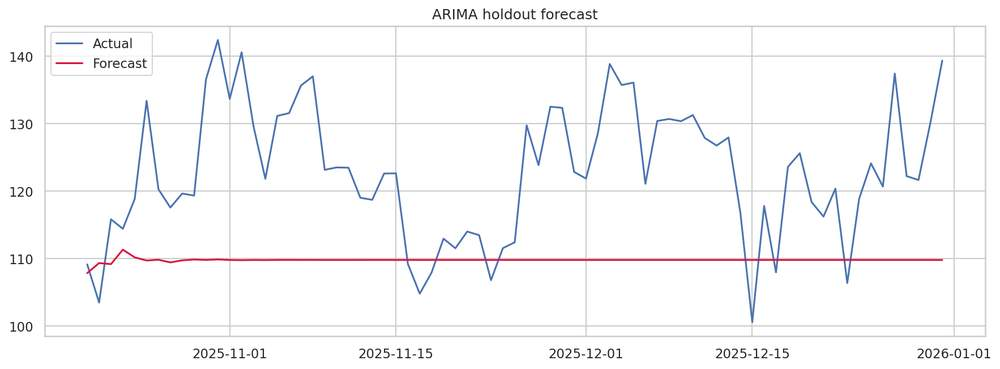

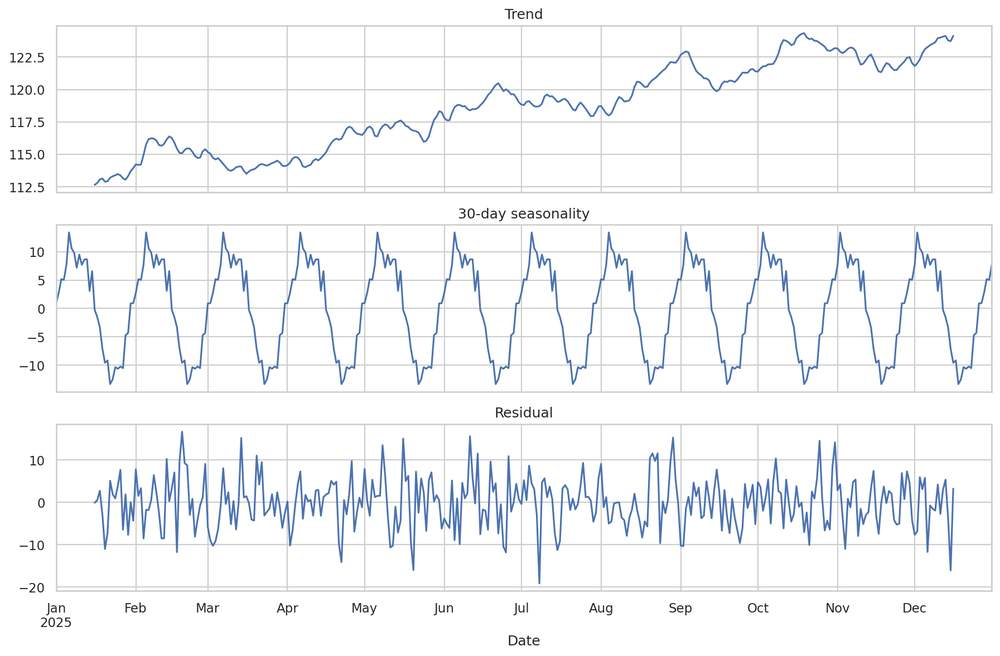

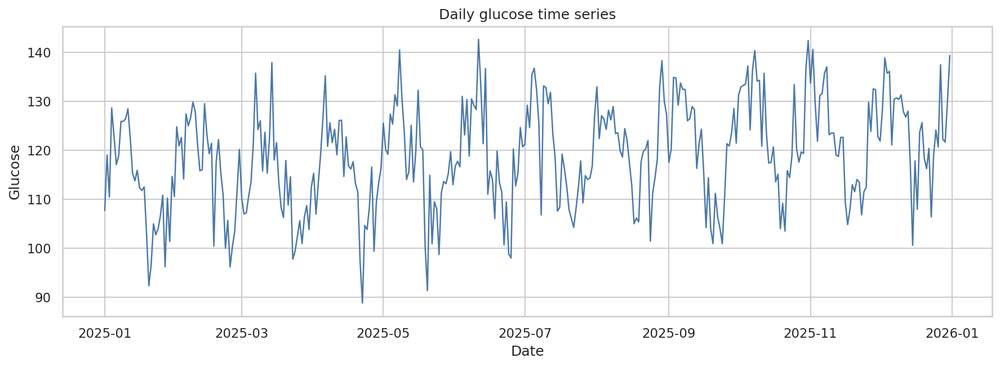

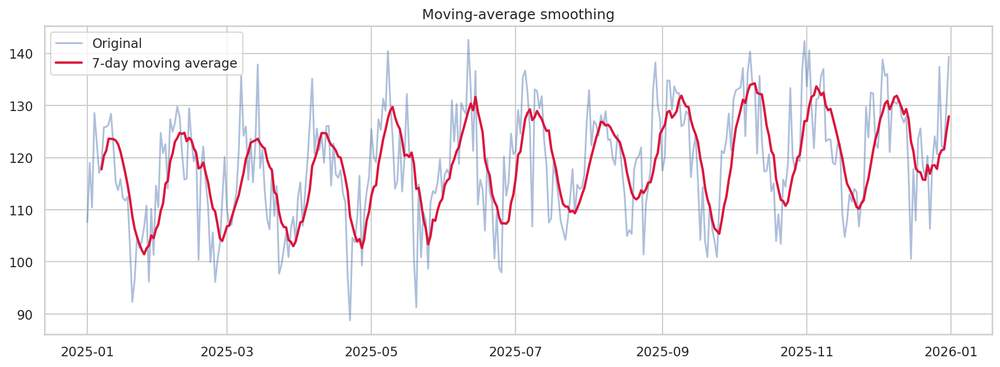

In [19]:
series = glucose_series.set_index("Date")["Glucose"].asfreq("D")
print(glucose_series.head())
plt.figure(figsize=(12, 4.5))
plt.plot(series.index, series, color="#4C78A8", linewidth=1.2)
plt.xlabel("Date")
plt.ylabel("Glucose")
plt.title("Daily glucose time series")
save_show("05c_glucose_time_series.png")

decomposition = seasonal_decompose(series, model="additive", period=30)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
decomposition.trend.plot(ax=axes[0], title="Trend")
decomposition.seasonal.plot(ax=axes[1], title="30-day seasonality")
decomposition.resid.plot(ax=axes[2], title="Residual")
save_show("05c_decomposition.png")

moving_average = series.rolling(7).mean()
plt.figure(figsize=(12, 4.5))
plt.plot(series.index, series, label="Original", alpha=0.45)
plt.plot(moving_average.index, moving_average, label="7-day moving average",
         color="crimson", linewidth=2)
plt.legend()
plt.title("Moving-average smoothing")
save_show("05c_moving_average.png")

train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]
fitted = ARIMA(train, order=(5, 1, 0)).fit()
forecast = fitted.forecast(steps=len(test))
forecast.index = test.index
rmse = mean_squared_error(test, forecast) ** 0.5
mae = mean_absolute_error(test, forecast)
forecast_table = pd.DataFrame({
    "Date": test.index, "Actual": test.to_numpy(),
    "Forecast": forecast.to_numpy()
})
forecast_table.to_csv(OUT_DIR / "05c_forecast_values.csv", index=False)
pd.DataFrame([{"Model": "ARIMA(5,1,0)", "RMSE": rmse, "MAE": mae}]).to_csv(
    OUT_DIR / "05c_forecast_metrics.csv", index=False
)
print(f"ARIMA RMSE: {rmse:.4f}; MAE: {mae:.4f}")
plt.figure(figsize=(12, 4.5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast", color="crimson")
plt.legend()
plt.title("ARIMA holdout forecast")
save_show("05c_arima_forecast.png")

## Final output package

In [20]:
output_index = pd.DataFrame([
    {"File": path.name, "Size (bytes)": path.stat().st_size}
    for path in sorted(OUT_DIR.iterdir()) if path.is_file()
])
output_index.to_csv(OUT_DIR / "OUTPUT_INDEX.csv", index=False)
zip_base = BASE_DIR / "DAV_All_Outputs"
zip_path = Path(shutil.make_archive(str(zip_base), "zip", OUT_DIR))
print(output_index.to_string(index=False))
print("\nAll 16 experiments completed successfully.")
print("Output ZIP:", zip_path)
print("In Colab, download it with:")
print("from google.colab import files; files.download(str(zip_path))")

                               File  Size (bytes)
                 01_bokeh_demo.html          6311
                01_library_demo.png         77208
            01_library_versions.csv           131
                01_plotly_demo.html          8655
             01_statsmodels_ols.txt          1837
           02a_numpy_operations.csv           105
           02b_category_summary.csv           195
               02b_cleaned_apps.csv           662
              02b_filtered_apps.csv           353
           02c_processed_excel.xlsx          5526
             02c_processed_text.csv           650
              02c_processed_web.csv            95
               02d_iris_boxplot.png         36738
            02d_iris_histograms.png         67424
              02d_iris_pairplot.png        266810
               02d_iris_summary.csv           369
            03a_pima_univariate.csv           893
   03a_uci_synthetic_univariate.csv           867
          03b_bivariate_metrics.csv           281
